In [1]:
url = "https://raw.githubusercontent.com/Adrian-Cancino/DataScience/refs/heads/main/Data/titanic3.csv"

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Descripción de variables

*pclass* - Passenger Class (1 = 1st; 2 = 2nd; 3 = 3rd)

*survival* - Survival (0 = No; 1 = Yes)

*name* - Name

*sex* - Sex

*age* - Age

*sibsp* - Number of Siblings/Spouses Aboard

*parch* - Number of Parents/Children Aboard

*ticket* - Ticket Number

*fare* - Passenger Fare

*cabin* - Cabin

*embarked* - Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

*boat* - Lifeboat

*body* - Body Identification Number

*home.dest* - Home/Destination

--------------------------------------------------------------------------

*Pclass* es un aproximado del estatus socioeconómico

*Age* es en años

In [6]:
df = pd.read_csv(url)
df.head()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [ ]:
#Analisisi Exploratorio de Datos (EDA)

In [10]:
df.shape

(1309, 14)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   object 
 3   sex        1309 non-null   object 
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   object 
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    object 
 10  embarked   1307 non-null   object 
 11  boat       486 non-null    object 
 12  body       121 non-null    float64
 13  home.dest  745 non-null    object 
dtypes: float64(3), int64(4), object(7)
memory usage: 143.3+ KB


In [ ]:
#Analisis de la variable objetivo (survived)
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [13]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

In [14]:
df[['sex','survived']].groupby('sex').mean()

,survived
sex,
female,0.727468
male,0.190985


In [ ]:
#Analisis de la variable pclass
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

In [ ]:
#porcentaje de sobrevivientes por clase
df[['pclass','survived']].groupby('pclass').mean()

,survived
pclass,
1,0.619195
2,0.429603
3,0.255289


In [ ]:
#sexo por clase
df.groupby('pclass')['sex'].value_counts().sort_values(ascending=False)

pclass  sex   
3       male      493
        female    216
1       male      179
2       male      171
1       female    144
2       female    106
Name: count, dtype: int64

In [ ]:
#posible relacion entre el numero de hermanos/cónyuges a bordo y la supervivencia
df[['sibsp', 'survived']].groupby('sibsp').mean().sort_values(by='survived', ascending=False)

,survived
sibsp,
1,0.510972
2,0.452381
0,0.346801
3,0.300000
4,0.136364
5,0.000000
8,0.000000


In [ ]:
# posible relacion entre el numero de padres/hijos a bordo y la supervivencia
df[['parch', 'survived']].groupby('parch').mean().sort_values(by='survived', ascending=False)

,survived
parch,
3,0.625000
1,0.588235
2,0.504425
0,0.335329
4,0.166667
5,0.166667
6,0.000000
9,0.000000


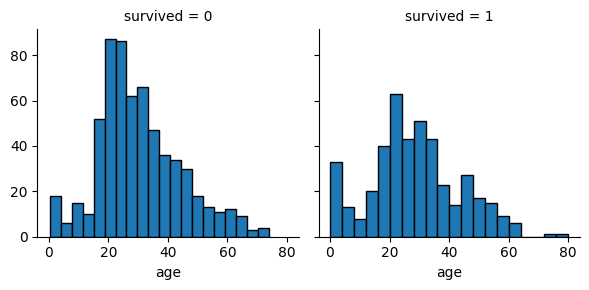

In [28]:
hist_age = sns.FacetGrid(df, col='survived')
hist_age.map(plt.hist, 'age', bins=20,  edgecolor='black')

In [16]:
df.columns


Index(['pclass', 'survived', 'name', 'sex', 'age', 'sibsp', 'parch', 'ticket',
       'fare', 'cabin', 'embarked', 'boat', 'body', 'home.dest'],
      dtype='object')

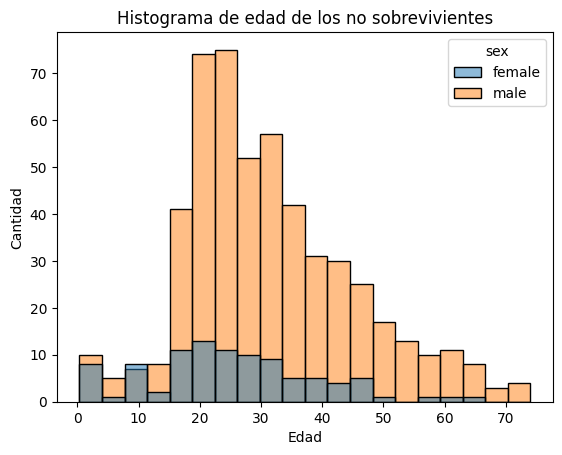

In [31]:
plt.Figure(figsize=(10,6))
sns.histplot(data=df[df['survived'] == 0], x='age', hue='sex', bins=20, label='No sobrevivio')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.title('Histograma de edad de los no sobrevivientes')
plt.show()

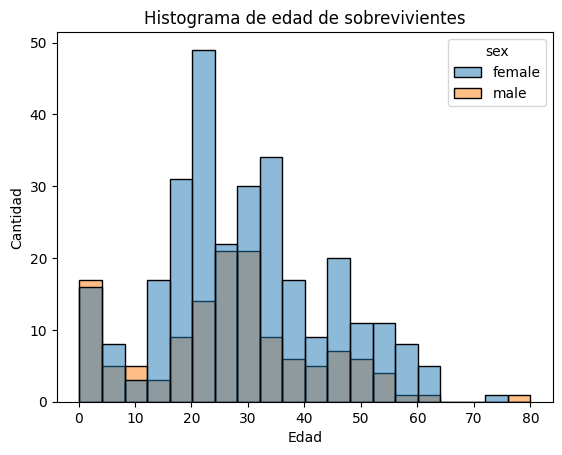

In [32]:
plt.Figure(figsize=(10,6))
sns.histplot(data=df[df['survived'] == 1], x='age', hue='sex', bins=20, label='Sobrevivio')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
plt.title('Histograma de edad de sobrevivientes')
plt.show()

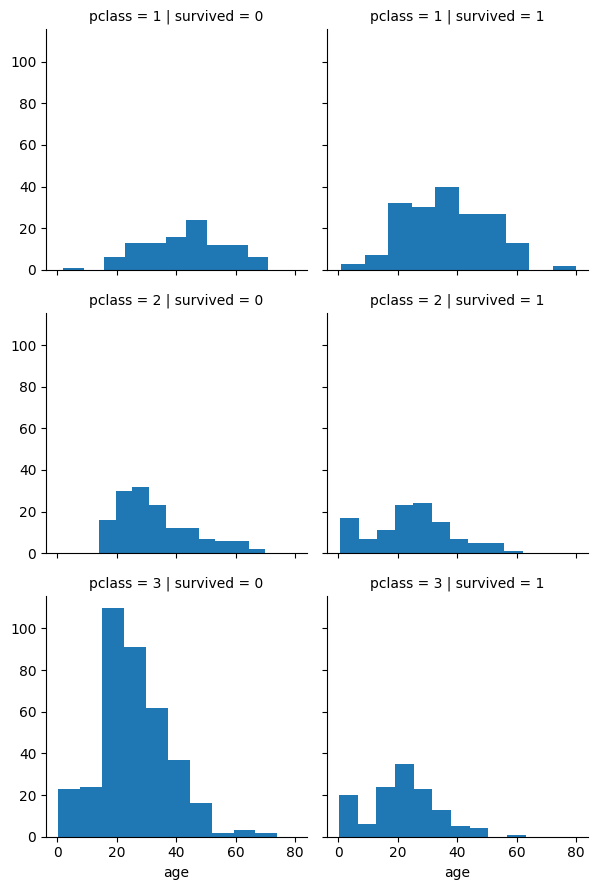

In [37]:
grid = sns.FacetGrid(df, col='survived', row='pclass')
grid.map(plt.hist, 'age', bins=10)
grid.add_legend()

### Modelo de ML

In [42]:
# Codificacion de variables categoricas female = 0 y male = 1
from sklearn.preprocessing import OneHotEncoder
one_hot_encoder = OneHotEncoder()
ohe = one_hot_encoder.fit_transform(df[['sex']])
ohe = ohe.astype(int)

In [43]:
one_hot_encoded_df = pd.DataFrame(ohe.toarray(), columns=one_hot_encoder.get_feature_names_out(['sex']))
one_hot_encoded_df

,sex_female,sex_male
0,1,0
1,0,1
2,1,0
3,0,1
4,1,0
...,...,...
1304,1,0
1305,1,0
1306,0,1
1307,0,1
